In [1]:
# ── Phase 10 : RFM scoring + segmentation ──
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

SERVER = "DESKTOP-LKG2222"
DATABASE = "FashionEcommerce"
engine = create_engine(
    f"mssql+pyodbc://{SERVER}/{DATABASE}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
    "&TrustServerCertificate=yes"
)

rfm = pd.read_sql("SELECT * FROM warehouse.Customer_RFM", engine)
print(rfm.shape)
rfm.describe()

(1283707, 4)


,Customer_Key,Recency_Days,Frequency,Monetary_USD
count,1.283707e+06,1.283707e+06,1.283707e+06,1.283707e+06
mean,7.787498e+05,2.177806e+02,3.378707e+00,2.330763e+02
std,4.754252e+05,1.943072e+02,2.632995e+00,2.236833e+02
min,1.000000e+00,0.000000e+00,1.000000e+00,1.778000e+00
25%,3.774625e+05,8.000000e+01,1.000000e+00,7.518400e+01
50%,7.555190e+05,1.400000e+02,3.000000e+00,1.629720e+02
75%,1.182388e+06,3.450000e+02,4.000000e+00,3.175000e+02
max,1.643306e+06,8.070000e+02,3.500000e+01,3.273925e+03


In [2]:
# ── Scores en quintiles (1 = pire, 5 = meilleur) ──
# Recency: plus petit = mieux -> on inverse l'ordre des labels
rfm["R_Score"] = pd.qcut(rfm["Recency_Days"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary_USD"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)
rfm["RFM_Sum"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]

rfm.head()

,Customer_Key,Recency_Days,Frequency,Monetary_USD,R_Score,F_Score,M_Score,RFM_Score,RFM_Sum
0,291856,38,4,281.960,5,4,4,544,13
1,821512,280,3,155.520,2,3,3,233,8
2,834175,156,5,518.076,3,4,5,345,12
3,866393,103,4,277.938,3,4,4,344,11
4,852656,78,3,393.822,4,3,5,435,12


In [3]:
# ── Segmentation business (basée sur R et F, standard RFM) ──
def segment_customer(row):
    r, f = row["R_Score"], row["F_Score"]
    if r >= 4 and f >= 4:
        return "VIP"
    elif r >= 3 and f >= 3:
        return "Loyal"
    elif r >= 4 and f <= 2:
        return "New Customers"
    elif r == 3 and f <= 2:
        return "Potential Loyalist"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and f <= 2:
        return "Lost"
    else:
        return "Others"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

segment_summary = rfm.groupby("Segment").agg(
    Nb_Customers=("Customer_Key", "count"),
    Avg_Recency=("Recency_Days", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary_USD", "mean"),
    Total_Monetary=("Monetary_USD", "sum")
).sort_values("Total_Monetary", ascending=False)

segment_summary["Pct_Customers"] = round(100 * segment_summary["Nb_Customers"] / len(rfm), 2)
segment_summary["Pct_Revenue"] = round(100 * segment_summary["Total_Monetary"] / rfm["Monetary_USD"].sum(), 2)

segment_summary

,Nb_Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Monetary,Pct_Customers,Pct_Revenue
Segment,,,,,,,
VIP,311467,56.173424,6.316563,429.604070,1.338075e+08,24.26,44.72
Loyal,269349,111.615280,3.804098,270.016505,7.272868e+07,20.98,24.31
At Risk,189408,343.282142,3.452056,240.300980,4.551493e+07,14.75,15.21
Lost,321642,460.829198,1.271177,88.257646,2.838737e+07,25.06,9.49
New Customers,108118,62.662304,1.493341,88.991840,9.621620e+06,8.42,3.22
Potential Loyalist,83723,143.204985,1.446090,109.189011,9.141632e+06,6.52,3.06


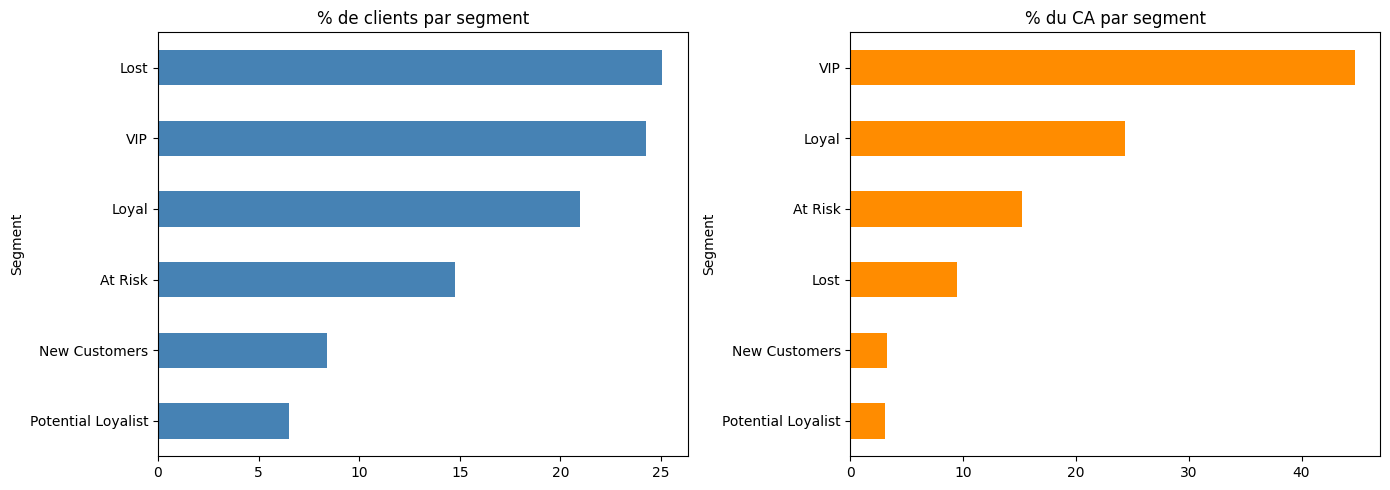

In [4]:
# ── Visualisation : taille du segment vs part du CA (le fameux "80/20") ──
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

segment_summary["Pct_Customers"].sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("% de clients par segment")

segment_summary["Pct_Revenue"].sort_values().plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("% du CA par segment")

plt.tight_layout()
plt.show()

In [5]:
# ── Renvoyer la segmentation vers SQL Server (pour Power BI) ──
rfm_export = rfm[["Customer_Key", "Recency_Days", "Frequency", "Monetary_USD",
                   "R_Score", "F_Score", "M_Score", "RFM_Score", "RFM_Sum", "Segment"]]

rfm_export.to_sql(
    "Customer_Segments",
    engine,
    schema="warehouse",
    if_exists="replace",
    index=False,
    chunksize=5000
)
print(f"{len(rfm_export)} clients segmentés exportés vers warehouse.Customer_Segments")

1283707 clients segmentés exportés vers warehouse.Customer_Segments
